In [1]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import StratifiedKFold, cross_validate
import warnings
warnings.filterwarnings('ignore')

# Load preprocessed data from Task 1
X_train = np.load('../data/processed/X_train_resampled.npy')
y_train = np.load('../data/processed/y_train_resampled.npy')
X_test = np.load('../data/processed/X_test_transformed.npy')
y_test = np.load('../data/processed/y_test.npy')

print("Data Loaded!")
print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)

Data Loaded!
X_train shape: (187004, 197)
X_test shape : (25830, 197)


=== Logistic Regression Results ===
AUC-PR : 0.3980183219690152
F1 Score: 0.2851770092388194
ROC-AUC: 0.7534081410060096

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.66      0.78     23376
           1       0.18      0.71      0.29      2454

    accuracy                           0.66     25830
   macro avg       0.57      0.68      0.53     25830
weighted avg       0.88      0.66      0.73     25830



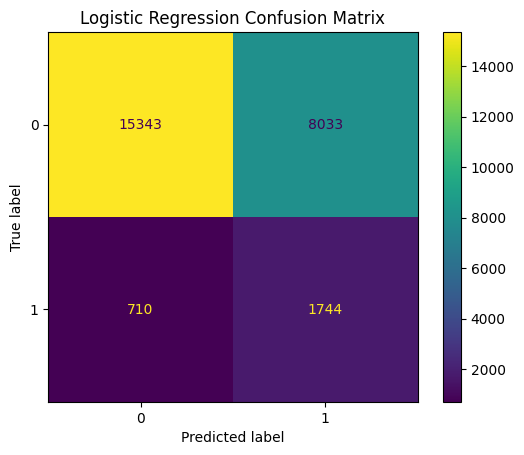

In [2]:
# Baseline Model
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train, y_train)

# Predictions
y_pred_lr = lr_model.predict(X_test)
y_pred_proba_lr = lr_model.predict_proba(X_test)[:, 1]

# Evaluation
print("=== Logistic Regression Results ===")
print("AUC-PR :", average_precision_score(y_test, y_pred_proba_lr))
print("F1 Score:", f1_score(y_test, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_proba_lr))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_lr)
ConfusionMatrixDisplay(cm).plot()
plt.title('Logistic Regression Confusion Matrix')
plt.show()

=== XGBoost Results ===
AUC-PR : 0.6271599213018618
F1 Score: 0.7021552843417295
ROC-AUC: 0.7706915649734721

Classification Report:
              precision    recall  f1-score   support

           0       0.95      1.00      0.98     23376
           1       0.97      0.55      0.70      2454

    accuracy                           0.96     25830
   macro avg       0.96      0.77      0.84     25830
weighted avg       0.96      0.96      0.95     25830



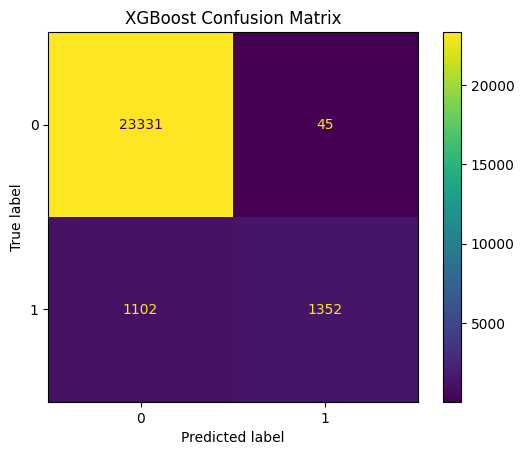

In [3]:
# XGBoost Model
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric='aucpr'
)

xgb_model.fit(X_train, y_train)

# Predictions
y_pred_xgb = xgb_model.predict(X_test)
y_pred_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

# Evaluation
print("=== XGBoost Results ===")
print("AUC-PR :", average_precision_score(y_test, y_pred_proba_xgb))
print("F1 Score:", f1_score(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_proba_xgb))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

# Confusion Matrix
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
ConfusionMatrixDisplay(cm_xgb).plot()
plt.title('XGBoost Confusion Matrix')
plt.show()

In [4]:
# Cross Validation on XGBoost
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = ['average_precision', 'f1', 'roc_auc']

cv_results = cross_validate(xgb_model, X_train, y_train, 
                           cv=cv, scoring=scoring, n_jobs=-1)

print("=== Cross-Validation Results (XGBoost) ===")
print("AUC-PR Mean :", cv_results['test_average_precision'].mean())
print("AUC-PR Std  :", cv_results['test_average_precision'].std())
print("F1 Mean     :", cv_results['test_f1'].mean())
print("ROC-AUC Mean:", cv_results['test_roc_auc'].mean())

=== Cross-Validation Results (XGBoost) ===
AUC-PR Mean : 0.982282558918477
AUC-PR Std  : 0.0006150289724104526
F1 Mean     : 0.949385472300279
ROC-AUC Mean: 0.9747339902364027
